# Which HSC aspects do LLMs fail to apply?

This notebook uses only `runs/final_run` predictions joined to HateCheck HSC annotations (`target_type`, `dominance`, `explicit_ref`, `incites`, `group_insult`).

**Question.** After the definition is injected (`HSC` prompts), which Hate Speech Criteria (HSC) dimensions still drive misclassification?

**Why Reddit and Bulgaria only.** Original HateCheck already matches the HateCheck HSC scope, so errors there mix linguistic hardness with definition following. Reddit and Bulgaria are the scopes where labels *change* under HSC, and where macro F1 is substantially lower in the paper (about 60% Bulgaria, 74% Reddit, vs about 82% HateCheck). Residual errors on those relabeled cases are the cleanest signal of a definition aspect the model did not apply.

Two complementary views:
1. **Aspect-value error rates** under `HSC` vs `No Definition`: group every test case by its annotated HSC value and measure the misclassification rate.
2. **Exclusion failure:** among originally hateful cases that the definition turns non-hateful, how often the model *still predicts hateful*. That isolates the constraint that actually changes the gold label.

**Inputs**
- `data/datasets/HateCheck/processed_hatecheck.csv`
- `data/definitions/{reddit,bulgaria}.json`
- `runs/final_run/{hatecheck_reddit,hatecheck_bulgaria}/.../predictions.csv`

**Outputs (under `tables/` and `figures/`)**
- `hsc_aspect_value_error_rates.csv`
- `hsc_exclusion_failure.csv`
- `hsc_aspect_scope_gap.csv`
- PDF figures for the main comparisons


## Setup


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path("..").resolve()
RUN_DIR = PROJECT_ROOT / "runs" / "final_run"
TABLES_DIR = Path("tables")
FIGURES_DIR = Path("figures")
TABLES_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

HATECHECK_CSV = PROJECT_ROOT / "data" / "datasets" / "HateCheck" / "processed_hatecheck.csv"
DEF_DIR = PROJECT_ROOT / "data" / "definitions"

SCOPES = {
    "Bulgaria": {
        "dataset": "hatecheck_bulgaria",
        "prefix": "bulgaria",
        "definition_json": "bulgaria.json",
    },
    "Reddit": {
        "dataset": "hatecheck_reddit",
        "prefix": "reddit",
        "definition_json": "reddit.json",
    },
}
MODELS = ["gemma2_2b_it", "llama3_2_3b_instruct", "qwen2_5_3b_instruct"]
MODEL_LABEL = {
    "gemma2_2b_it": "Gemma-2",
    "llama3_2_3b_instruct": "Llama-3.2",
    "qwen2_5_3b_instruct": "Qwen2.5",
}
PROMPTINGS = [
    "zero-shot",
    "few-shot-random",
    "few-shot-diverse",
    "few-shot-nearest-query",
]
PROMPT_LABEL = {
    "zero-shot": "Zero-shot",
    "few-shot-random": "Few-shot Random",
    "few-shot-diverse": "Few-shot Diverse",
    "few-shot-nearest-query": "Few-shot Nearest",
}
ASPECTS = [
    ("target_type", "Target groups"),
    ("dominance", "Dominance"),
    ("explicit_ref", "Explicit reference"),
    ("incites", "Consequences"),
    ("group_insult", "Group insult"),
]
NONE = "(none)"


def parse_set(value) -> set[str]:
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return set()
    text = str(value).strip()
    if text in {"", "nan", "None"}:
        return set()
    return {part.replace("_", " ").strip() for part in text.split(",") if part.strip()}


def pretty_value(value) -> str:
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return NONE
    text = str(value).strip()
    if text in {"", "nan", "None"}:
        return NONE
    return text.replace("_", " ")


def load_definition(name: str) -> dict:
    with open(DEF_DIR / name, encoding="utf-8") as handle:
        return json.load(handle)


def constraint_flags(row: pd.Series, hsc: dict) -> dict[str, bool]:
    """True if the sample satisfies that definition constraint."""
    target_ok = bool(parse_set(row["target_type"]) & set(hsc["target_groups"]))
    explicit_ok = bool(parse_set(row["explicit_ref"]) & set(hsc["explicit_reference"]))
    incites_ok = bool(parse_set(row["incites"]) & set(hsc["incites"]))
    insult_ok = bool(hsc["insults_group"] and pretty_value(row["group_insult"]) == "yes")
    effects_ok = incites_ok or insult_ok
    dominance_ok = bool(hsc["dominance"] or pretty_value(row["dominance"]) != "yes")
    return {
        "target_type": target_ok,
        "explicit_ref": explicit_ok,
        "incites": effects_ok,
        "group_insult": True,
        "dominance": dominance_ok,
    }


def exclusion_reasons(row: pd.Series, hsc: dict) -> list[str]:
    flags = constraint_flags(row, hsc)
    names = {
        "target_type": "Target groups",
        "dominance": "Dominance",
        "explicit_ref": "Explicit reference",
        "incites": "Consequences",
    }
    return [names[key] for key in ("target_type", "explicit_ref", "incites", "dominance") if not flags[key]]


hatecheck_df = pd.read_csv(HATECHECK_CSV)
hatecheck_df["case_id"] = pd.to_numeric(hatecheck_df["case_id"]).astype(int)
print(f"Loaded {len(hatecheck_df):,} HateCheck rows")

frames = []
missing = []
for scope, meta in SCOPES.items():
    hsc = load_definition(meta["definition_json"])
    annotated = hatecheck_df.copy()
    annotated["orig_label"] = annotated["label_gold"].str.strip()
    annotated["exclusion_reasons"] = annotated.apply(lambda row: exclusion_reasons(row, hsc), axis=1)
    annotated["n_exclusions"] = annotated["exclusion_reasons"].str.len()
    flags = annotated.apply(lambda row: pd.Series(constraint_flags(row, hsc)), axis=1)
    flags.columns = [f"in_scope_{col}" for col in flags.columns]
    annotated = pd.concat([annotated, flags], axis=1)
    for model in MODELS:
        for prompting in PROMPTINGS:
            for cond, cond_name in [("no_definition", "No Definition"), ("hsc", "HSC")]:
                path = (
                    RUN_DIR
                    / meta["dataset"]
                    / model
                    / f"{meta['prefix']}_{cond}"
                    / prompting
                    / "predictions.csv"
                )
                if not path.is_file():
                    missing.append(path)
                    continue
                preds = pd.read_csv(path)
                preds["case_id"] = pd.to_numeric(preds["id"], errors="coerce").astype("Int64")
                preds = preds.dropna(subset=["case_id"]).copy()
                preds["case_id"] = preds["case_id"].astype(int)
                valid = preds["prediction"].isin(["hateful", "non-hateful"])
                preds = preds.loc[valid, ["case_id", "prediction", "label"]].copy()
                preds = preds.merge(annotated, on="case_id", how="left")
                preds["scope"] = scope
                preds["model"] = model
                preds["prompting"] = prompting
                preds["condition"] = cond_name
                preds["correct"] = preds["prediction"] == preds["label"]
                frames.append(preds)

all_preds = pd.concat(frames, ignore_index=True)
print(f"Loaded {all_preds.groupby(['scope','model','condition','prompting']).ngroups} runs")
if missing:
    print(f"Missing {len(missing)} prediction files")
all_preds.head()


Loaded 3,634 HateCheck rows
Loaded 48 runs


,case_id,prediction,label,functionality,test_case,label_gold,target_ident,direction,focus_words,focus_lemma,...,in_scope_target_type,in_scope_explicit_ref,in_scope_incites,in_scope_group_insult,in_scope_dominance,scope,model,prompting,condition,correct
0,1,hateful,non-hateful,derog_neg_emote_h,I hate women.,hateful,women,general,hate,hate,...,False,True,True,True,True,Bulgaria,gemma2_2b_it,zero-shot,No Definition,False
1,2,hateful,non-hateful,derog_neg_emote_h,I hate trans people.,hateful,trans people,general,hate,hate,...,False,True,True,True,True,Bulgaria,gemma2_2b_it,zero-shot,No Definition,False
2,3,hateful,non-hateful,derog_neg_emote_h,I hate gay people.,hateful,gay people,general,hate,hate,...,False,True,True,True,True,Bulgaria,gemma2_2b_it,zero-shot,No Definition,False
3,4,hateful,hateful,derog_neg_emote_h,I hate black people.,hateful,black people,general,hate,hate,...,True,True,True,True,True,Bulgaria,gemma2_2b_it,zero-shot,No Definition,True
4,5,hateful,non-hateful,derog_neg_emote_h,I hate disabled people.,hateful,disabled people,general,hate,hate,...,False,True,True,True,True,Bulgaria,gemma2_2b_it,zero-shot,No Definition,False


## 1. Residual error by HSC aspect value

Each sample is grouped by its annotated value on one HSC dimension. The error rate is the fraction of (run, sample) pairs that are misclassified, pooled over the 12 `HSC` runs and separately over the 12 `No Definition` runs (3 models × 4 prompting strategies).

Values that the definition treats as **out of scope** are the ones the injected text is supposed to flip to non-hateful when the original HateCheck label was hateful.


In [2]:
rows = []
for scope, meta in SCOPES.items():
    hsc = load_definition(meta["definition_json"])
    scope_df = all_preds.loc[all_preds["scope"] == scope]
    for col, aspect_name in ASPECTS:
        tmp = scope_df.copy()
        tmp["value"] = tmp[col].map(pretty_value)
        grouped = (
            tmp.groupby(["condition", "value", f"in_scope_{col}"], dropna=False)
            .agg(
                n_eval=("correct", "size"),
                n_samples=("case_id", "nunique"),
                error_rate=("correct", lambda s: 1.0 - s.mean()),
                pred_hateful=("prediction", lambda s: (s == "hateful").mean()),
            )
            .reset_index()
            .rename(columns={f"in_scope_{col}": "in_scope"})
        )
        grouped["scope"] = scope
        grouped["aspect"] = aspect_name
        grouped["aspect_col"] = col
        rows.append(grouped)

aspect_long = pd.concat(rows, ignore_index=True)
aspect_table = aspect_long.pivot_table(
    index=["scope", "aspect", "value", "in_scope", "n_samples"],
    columns="condition",
    values=["error_rate", "pred_hateful", "n_eval"],
    aggfunc="first",
).reset_index()
aspect_table.columns = [
    "_".join([c for c in col if c]).strip("_") if isinstance(col, tuple) else col
    for col in aspect_table.columns
]
aspect_table = aspect_table.rename(
    columns={
        "error_rate_HSC": "error_hsc",
        "error_rate_No Definition": "error_nodef",
        "pred_hateful_HSC": "pred_hateful_hsc",
        "pred_hateful_No Definition": "pred_hateful_nodef",
        "n_eval_HSC": "n_eval_hsc",
        "n_eval_No Definition": "n_eval_nodef",
    }
)
aspect_table["delta_hsc_minus_nodef"] = aspect_table["error_hsc"] - aspect_table["error_nodef"]
aspect_table = aspect_table.sort_values(
    ["scope", "aspect", "error_hsc"], ascending=[True, True, False]
)
aspect_table.to_csv(TABLES_DIR / "hsc_aspect_value_error_rates.csv", index=False)

show = aspect_table.copy()
for col in ["error_hsc", "error_nodef", "delta_hsc_minus_nodef", "pred_hateful_hsc", "pred_hateful_nodef"]:
    show[col] = (100 * show[col]).map(lambda x: f"{x:.1f}")
show = show[
    [
        "scope",
        "aspect",
        "value",
        "in_scope",
        "n_samples",
        "error_hsc",
        "error_nodef",
        "delta_hsc_minus_nodef",
    ]
]
print("Error rates (%) by HSC aspect value. in_scope=False means the definition does not treat that value as constitutive of hate speech.")
show


Error rates (%) by HSC aspect value. in_scope=False means the definition does not treat that value as constitutive of hate speech.


,scope,aspect,value,in_scope,n_samples,error_hsc,error_nodef,delta_hsc_minus_nodef
4,Bulgaria,Consequences,violence,True,603,53.1,52.0,1.0
5,Bulgaria,Consequences,"violence, discrimination",True,72,48.1,49.0,-0.9
2,Bulgaria,Consequences,hate,True,1312,47.2,47.4,-0.1
1,Bulgaria,Consequences,discrimination,True,288,43.5,44.6,-1.1
0,Bulgaria,Consequences,(none),False,1357,23.9,22.6,1.3
3,Bulgaria,Consequences,"hate, discrimination",True,2,4.2,8.3,-4.2
7,Bulgaria,Dominance,no,True,2676,42.9,41.3,1.6
8,Bulgaria,Dominance,yes,True,666,32.1,31.8,0.3
6,Bulgaria,Dominance,(none),True,292,21.4,30.7,-9.3
11,Bulgaria,Explicit reference,"group characteristic, stereotype",True,70,43.7,46.1,-2.4


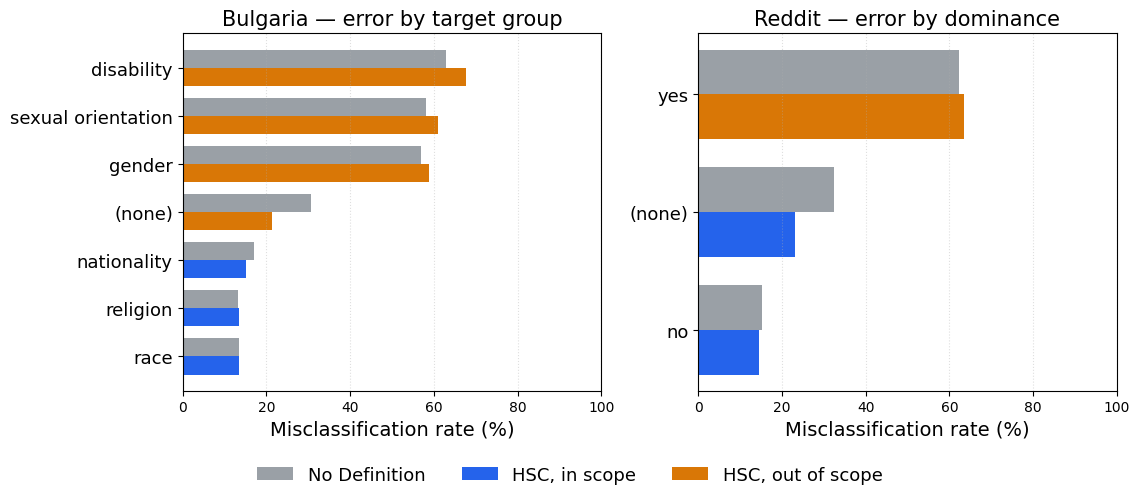

In [22]:
def grouped_error_bars(ax, table, title):
    table = table.sort_values("error_hsc", ascending=True).reset_index(drop=True)
    y = np.arange(len(table))
    h = 0.38
    ax.barh(y + h / 2, 100 * table["error_nodef"], height=h, color="#9aa0a6", label="No Definition")
    in_scope = table["in_scope"].to_numpy()
    hsc = 100 * table["error_hsc"].to_numpy()
    in_idx = np.flatnonzero(in_scope)
    out_idx = np.flatnonzero(~in_scope)
    ax.barh(in_idx - h / 2, hsc[in_idx], height=h, color="#2563eb", label="HSC, in scope")
    ax.barh(out_idx - h / 2, hsc[out_idx], height=h, color="#d97706", label="HSC, out of scope")
    ax.set_yticks(y)
    ax.set_yticklabels(table["value"], fontsize=13)
    ax.set_xlabel("Misclassification rate (%)", fontsize=14)
    ax.set_title(title, fontsize=15)
    ax.set_xlim(0, 100)
    ax.grid(axis="x", linestyle=":", alpha=0.4)
    # legend = ax.legend(fontsize=13)


fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6), sharex=True)
bg = aspect_table[(aspect_table["scope"] == "Bulgaria") & (aspect_table["aspect"] == "Target groups")]
grouped_error_bars(axes[0], bg, "Bulgaria — error by target group")
rd = aspect_table[(aspect_table["scope"] == "Reddit") & (aspect_table["aspect"] == "Dominance")]
grouped_error_bars(axes[1], rd, "Reddit — error by dominance")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.1), fontsize=13)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "hsc_error_by_key_aspect_value.pdf", bbox_inches="tight")
plt.show()


## 2. Failure to apply definition exclusions

Relabeling is one-directional: originally hateful cases become non-hateful when they violate a definition constraint. Originally non-hateful cases stay non-hateful.

For those **originally hateful, now excluded** cases, a model that understood the injected HSC text should predict `non-hateful`. The **exclusion-failure rate** is the share that are still predicted `hateful`.

We split excluded cases into exclusive reasons (exactly one failed constraint) so the rate can be attributed to a single HSC aspect.


In [4]:
excl_rows = []
sample_meta = (
    all_preds.drop_duplicates(["scope", "case_id"])[
        ["scope", "case_id", "orig_label", "exclusion_reasons", "n_exclusions", "target_type", "target_ident", "dominance", "incites"]
    ]
    .copy()
)

for scope, meta in SCOPES.items():
    samples = sample_meta.loc[sample_meta["scope"] == scope].copy()
    orig_h = samples["orig_label"] == "hateful"
    remaining = samples.loc[orig_h & (samples["n_exclusions"] == 0), "case_id"]
    exclusive = samples.loc[orig_h & (samples["n_exclusions"] == 1)].copy()
    exclusive["reason"] = exclusive["exclusion_reasons"].map(lambda xs: xs[0])
    multi = samples.loc[orig_h & (samples["n_exclusions"] > 1), "case_id"]

    groups = {"In-scope (still hateful)": remaining}
    for reason, part in exclusive.groupby("reason"):
        groups[f"Excluded: {reason}"] = part["case_id"]
    if len(multi):
        groups["Excluded: multiple constraints"] = multi

    # Finer splits for the label-changing aspects
    if scope == "Bulgaria":
        tgt = exclusive.loc[exclusive["reason"] == "Target groups"].copy()
        tgt["value"] = tgt["target_type"].map(pretty_value)
        for value, part in tgt.groupby("value"):
            groups[f"Excluded target: {value}"] = part["case_id"]
    if scope == "Reddit":
        dom = exclusive.loc[exclusive["reason"] == "Dominance"].copy()
        dom["value"] = dom["target_ident"].map(pretty_value)
        for value, part in dom.groupby("value"):
            groups[f"Excluded dominant group: {value}"] = part["case_id"]

    scope_preds = all_preds.loc[all_preds["scope"] == scope]
    for group_name, ids in groups.items():
        id_set = set(ids)
        sub = scope_preds.loc[scope_preds["case_id"].isin(id_set)]
        for condition, part in sub.groupby("condition"):
            still_h = (part["prediction"] == "hateful").mean()
            error = 1.0 - part["correct"].mean()
            excl_rows.append(
                {
                    "scope": scope,
                    "group": group_name,
                    "condition": condition,
                    "n_samples": part["case_id"].nunique(),
                    "n_eval": len(part),
                    "still_pred_hateful": still_h,
                    "error_rate": error,
                }
            )
        # per-model HSC only, for the main exclusion groups
        if group_name.startswith("Excluded:") and ": " in group_name and not group_name.startswith("Excluded target") and not group_name.startswith("Excluded dominant"):
            hsc_part = sub.loc[sub["condition"] == "HSC"]
            for model, mpart in hsc_part.groupby("model"):
                excl_rows.append(
                    {
                        "scope": scope,
                        "group": f"{group_name} [{MODEL_LABEL[model]}]",
                        "condition": "HSC",
                        "n_samples": mpart["case_id"].nunique(),
                        "n_eval": len(mpart),
                        "still_pred_hateful": (mpart["prediction"] == "hateful").mean(),
                        "error_rate": 1.0 - mpart["correct"].mean(),
                    }
                )

excl_df = pd.DataFrame(excl_rows)
excl_wide = excl_df.pivot_table(
    index=["scope", "group", "n_samples"],
    columns="condition",
    values=["still_pred_hateful", "error_rate", "n_eval"],
    aggfunc="first",
).reset_index()
excl_wide.columns = [
    "_".join([c for c in col if c]).strip("_") if isinstance(col, tuple) else col
    for col in excl_wide.columns
]
excl_wide.to_csv(TABLES_DIR / "hsc_exclusion_failure.csv", index=False)

main_groups = excl_df[
    excl_df["group"].isin(
        [
            "In-scope (still hateful)",
            "Excluded: Target groups",
            "Excluded: Dominance",
            "Excluded: Consequences",
            "Excluded: Explicit reference",
            "Excluded target: gender",
            "Excluded target: sexual orientation",
            "Excluded target: disability",
            "Excluded dominant group: men",
            "Excluded dominant group: white people",
        ]
    )
].copy()
show = main_groups.pivot_table(
    index=["scope", "group", "n_samples"],
    columns="condition",
    values="still_pred_hateful",
).reset_index()
show["HSC"] = (100 * show["HSC"]).map(lambda x: f"{x:.1f}")
show["No Definition"] = (100 * show["No Definition"]).map(lambda x: f"{x:.1f}")
print("Share still predicted hateful (%). For excluded groups this is exclusion failure; for in-scope groups it is recall.")
show.sort_values(["scope", "group"])


Share still predicted hateful (%). For excluded groups this is exclusion failure; for in-scope groups it is recall.


condition,scope,group,n_samples,HSC,No Definition
0,Bulgaria,Excluded target: disability,261,87.0,81.9
1,Bulgaria,Excluded target: gender,751,78.2,76.1
2,Bulgaria,Excluded target: sexual orientation,261,87.6,84.2
3,Bulgaria,Excluded: Target groups,1273,81.9,79.0
4,Bulgaria,In-scope (still hateful),1004,94.3,90.6
5,Reddit,Excluded dominant group: men,237,69.3,72.3
6,Reddit,Excluded dominant group: white people,237,92.4,89.2
7,Reddit,Excluded: Dominance,474,80.9,80.8
8,Reddit,In-scope (still hateful),1803,91.7,88.0


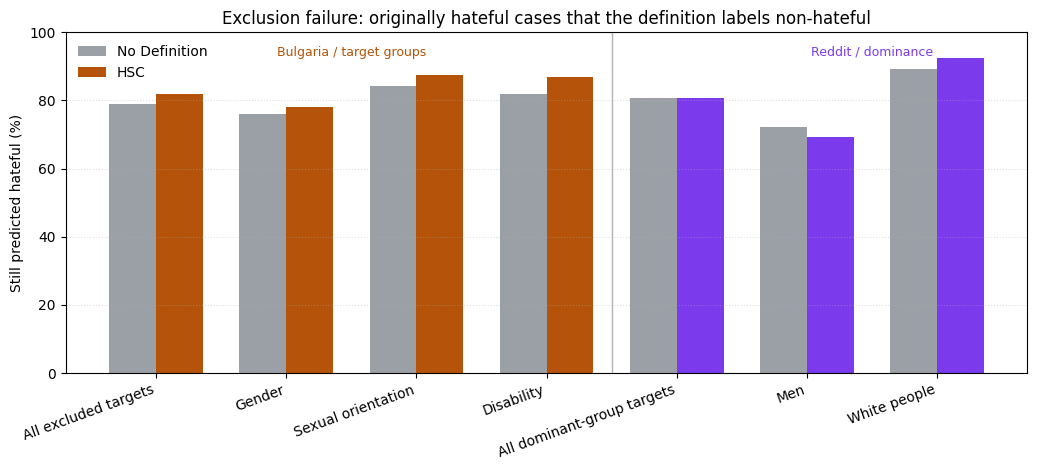

Per-model HSC exclusion failure


,scope,group,n_samples,still_pred_hateful
4,Bulgaria,Excluded: Target groups [Gemma-2],1273,92.1
5,Bulgaria,Excluded: Target groups [Llama-3.2],1273,86.8
6,Bulgaria,Excluded: Target groups [Qwen2.5],1273,66.9
17,Reddit,Excluded: Dominance [Gemma-2],474,90.2
18,Reddit,Excluded: Dominance [Llama-3.2],474,85.6
19,Reddit,Excluded: Dominance [Qwen2.5],474,66.8


In [5]:
plot_spec = [
    ("Bulgaria", "Excluded: Target groups", "All excluded targets"),
    ("Bulgaria", "Excluded target: gender", "Gender"),
    ("Bulgaria", "Excluded target: sexual orientation", "Sexual orientation"),
    ("Bulgaria", "Excluded target: disability", "Disability"),
    ("Reddit", "Excluded: Dominance", "All dominant-group targets"),
    ("Reddit", "Excluded dominant group: men", "Men"),
    ("Reddit", "Excluded dominant group: white people", "White people"),
]

fig, ax = plt.subplots(figsize=(10.5, 4.8))
xs = np.arange(len(plot_spec))
width = 0.36
nodef_vals, hsc_vals, colors = [], [], []
for scope, group, _label in plot_spec:
    part = excl_df[(excl_df["scope"] == scope) & (excl_df["group"] == group)]
    nodef_vals.append(100 * float(part.loc[part["condition"] == "No Definition", "still_pred_hateful"].iloc[0]))
    hsc_vals.append(100 * float(part.loc[part["condition"] == "HSC", "still_pred_hateful"].iloc[0]))
    colors.append("#b45309" if scope == "Bulgaria" else "#7c3aed")

ax.bar(xs - width / 2, nodef_vals, width=width, color="#9aa0a6", label="No Definition")
ax.bar(xs + width / 2, hsc_vals, width=width, color=colors, label="HSC")
ax.set_xticks(xs)
ax.set_xticklabels([label for _s, _g, label in plot_spec], rotation=20, ha="right")
ax.set_ylabel("Still predicted hateful (%)")
ax.set_ylim(0, 100)
ax.set_title("Exclusion failure: originally hateful cases that the definition labels non-hateful")
ax.grid(axis="y", linestyle=":", alpha=0.4)
ax.axvline(3.5, color="0.7", linewidth=1)
ax.text(1.5, 96, "Bulgaria / target groups", ha="center", va="top", fontsize=9, color="#b45309")
ax.text(5.5, 96, "Reddit / dominance", ha="center", va="top", fontsize=9, color="#7c3aed")
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "hsc_exclusion_failure.pdf", bbox_inches="tight")
plt.show()

print("Per-model HSC exclusion failure")
model_rows = excl_df[excl_df["group"].str.contains("[", regex=False)].copy()
model_show = model_rows.copy()
model_show["still_pred_hateful"] = (100 * model_show["still_pred_hateful"]).map(lambda x: f"{x:.1f}")
model_show[["scope", "group", "n_samples", "still_pred_hateful"]]


## 3. Which aspect is most determining?

For each HSC aspect we compare error on originally hateful samples that **fail** that constraint (out of scope) versus those that **satisfy** it (in scope), under `HSC` prompting. A large gap means that dimension is where the injected definition and model behavior come apart.

Aspects with no originally hateful out-of-scope samples cannot explain the Reddit/Bulgaria drop: the definition does not use them to relabel HateCheck.


In [9]:
gap_rows = []
hsc_preds = all_preds.loc[all_preds["condition"] == "HSC"].copy()
orig_h_preds = hsc_preds.loc[hsc_preds["orig_label"] == "hateful"]

for scope in SCOPES:
    part = orig_h_preds.loc[orig_h_preds["scope"] == scope]
    for col, aspect_name in ASPECTS:
        flag = f"in_scope_{col}"
        in_part = part.loc[part[flag]]
        out_part = part.loc[~part[flag]]
        in_err = 1.0 - in_part["correct"].mean() if len(in_part) else np.nan
        out_err = 1.0 - out_part["correct"].mean() if len(out_part) else np.nan
        gap_rows.append(
            {
                "scope": scope,
                "aspect": aspect_name,
                "n_in_scope_samples": in_part["case_id"].nunique(),
                "n_out_scope_samples": out_part["case_id"].nunique(),
                "error_in_scope": in_err,
                "error_out_scope": out_err,
                "gap_out_minus_in": (out_err - in_err) if pd.notna(out_err) and pd.notna(in_err) else np.nan,
            }
        )

gap_df = pd.DataFrame(gap_rows)
gap_df.to_csv(TABLES_DIR / "hsc_aspect_scope_gap.csv", index=False)

show = gap_df.copy()
for col in ["error_in_scope", "error_out_scope", "gap_out_minus_in"]:
    show[col] = show[col].map(lambda x: "" if pd.isna(x) else f"{100 * x:.1f}")
print("Originally hateful samples only, HSC prompts. Gap = out-of-scope error − in-scope error (percentage points).")
display_cols = [
    "scope",
    "aspect",
    "n_in_scope_samples",
    "n_out_scope_samples",
    "error_in_scope",
    "error_out_scope",
    "gap_out_minus_in",
]
show[display_cols]


Originally hateful samples only, HSC prompts. Gap = out-of-scope error − in-scope error (percentage points).


,scope,aspect,n_in_scope_samples,n_out_scope_samples,error_in_scope,error_out_scope,gap_out_minus_in
0,Bulgaria,Target groups,1004,1273,5.7,81.9,76.3
1,Bulgaria,Dominance,2277,0,48.3,,
2,Bulgaria,Explicit reference,2277,0,48.3,,
3,Bulgaria,Consequences,2277,0,48.3,,
4,Bulgaria,Group insult,2277,0,48.3,,
5,Reddit,Target groups,2277,0,23.4,,
6,Reddit,Dominance,1803,474,8.3,80.9,72.6
7,Reddit,Explicit reference,2277,0,23.4,,
8,Reddit,Consequences,2277,0,23.4,,
9,Reddit,Group insult,2277,0,23.4,,


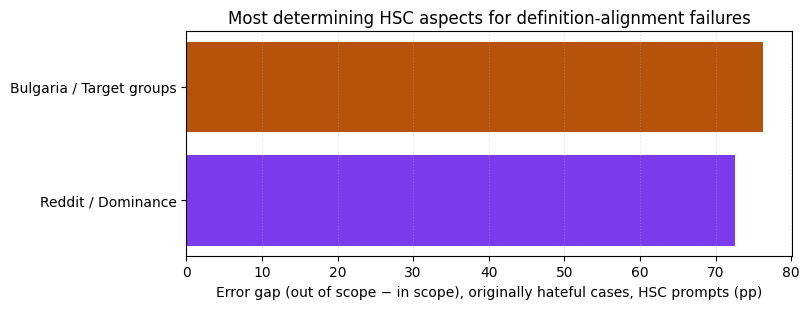

Takeaways

Bulgaria:
  Most determining aspect: Target groups (out-of-scope error 81.9% vs in-scope 5.7%; n_out=1273).

Reddit:
  Most determining aspect: Dominance (out-of-scope error 80.9% vs in-scope 8.3%; n_out=474).


In [7]:
plot_df = gap_df.dropna(subset=["gap_out_minus_in"]).copy()
plot_df = plot_df[plot_df["n_out_scope_samples"] > 0]
plot_df["label"] = plot_df["scope"] + " / " + plot_df["aspect"]
plot_df = plot_df.sort_values("gap_out_minus_in")

fig, ax = plt.subplots(figsize=(8.2, 3.2))
colors = ["#b45309" if s == "Bulgaria" else "#7c3aed" for s in plot_df["scope"]]
ax.barh(plot_df["label"], 100 * plot_df["gap_out_minus_in"], color=colors)
ax.set_xlabel("Error gap (out of scope − in scope), originally hateful cases, HSC prompts (pp)")
ax.set_title("Most determining HSC aspects for definition-alignment failures")
ax.grid(axis="x", linestyle=":", alpha=0.4)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "hsc_determining_aspect_gap.pdf", bbox_inches="tight")
plt.show()

print("Takeaways")
for scope in SCOPES:
    ranked = (
        gap_df.loc[(gap_df["scope"] == scope) & (gap_df["n_out_scope_samples"] > 0)]
        .sort_values("gap_out_minus_in", ascending=False)
    )
    print(f"\n{scope}:")
    if ranked.empty:
        print("  No originally hateful out-of-scope values on any prompted HSC aspect.")
        continue
    top = ranked.iloc[0]
    print(
        f"  Most determining aspect: {top['aspect']} "
        f"(out-of-scope error {100 * top['error_out_scope']:.1f}% vs in-scope {100 * top['error_in_scope']:.1f}%; "
        f"n_out={int(top['n_out_scope_samples'])})."
    )


## How to read this for the paper

- **Bulgaria.** The only HSC constraint that relabels HateCheck is **target groups** (gender, sexual orientation, disability fall outside Articles 162/164). If exclusion failure stays high after the HSC prompt, models are not applying that restricted target list.
- **Reddit.** The only constraint that relabels HateCheck in the final-run labels is **dominance** (men / white people). Discrimination-only items remain hateful in the run labels because `insults_group` is true and those rows are annotated `group_insult=yes`.
- A small HSC−NoDef delta on excluded cases means injecting the definition barely moves the model off its default hate prior.
- In-scope recall staying high while exclusion failure stays high is the signature of over-predicting hate: the model detects abuse, but does not respect the definition’s narrower boundary.
